In [3]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 连接OKX
exchange = ccxt.okx()

# 测试：拉取BTC/USDT日线数据
ohlcv = exchange.fetch_ohlcv("BTC/USDT", timeframe="1d", limit=10)
df = pd.DataFrame(ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
df["date"] = pd.to_datetime(df["timestamp"], unit="ms")
df = df.set_index("date")

print(df)

                timestamp     open     high      low    close        volume
date                                                                       
2026-03-19  1773878400000  71253.1  71618.0  68796.3  69923.7   7331.205854
2026-03-20  1773964800000  69923.7  71366.0  69393.5  70515.7   5670.280110
2026-03-21  1774051200000  70515.6  71100.0  68555.0  68921.1   3290.103972
2026-03-22  1774137600000  68921.1  69584.8  67360.1  67860.1   4774.157931
2026-03-23  1774224000000  67860.1  71809.4  67452.4  70900.0  10569.061730
2026-03-24  1774310400000  70900.0  71400.0  68924.0  70557.5   6869.959830
2026-03-25  1774396800000  70557.5  72012.0  70414.1  71334.9   5943.669683
2026-03-26  1774483200000  71334.9  71440.9  68153.3  68827.2   6581.532381
2026-03-27  1774569600000  68827.2  69185.6  65559.6  66403.9   9636.054943
2026-03-28  1774656000000  66403.9  67169.0  65933.2  66736.1   2443.163999


In [4]:
# 拉取更长的历史数据（500天）
ohlcv = exchange.fetch_ohlcv("BTC/USDT", timeframe="1d", limit=500)
df_btc = pd.DataFrame(ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
df_btc["date"] = pd.to_datetime(df_btc["timestamp"], unit="ms")
df_btc = df_btc.set_index("date")
df_btc = df_btc.drop(columns=["timestamp"])

# 保存本地
df_btc.to_csv("btc_daily.csv")

print(f"数据维度：{df_btc.shape}")
print(f"时间范围：{df_btc.index[0].date()} 到 {df_btc.index[-1].date()}")
print(df_btc.tail())

数据维度：(300, 5)
时间范围：2025-06-02 到 2026-03-28
               open     high      low    close       volume
date                                                       
2026-03-24  70900.0  71400.0  68924.0  70557.5  6869.959830
2026-03-25  70557.5  72012.0  70414.1  71334.9  5943.669683
2026-03-26  71334.9  71440.9  68153.3  68827.2  6581.532381
2026-03-27  68827.2  69185.6  65559.6  66403.9  9636.054943
2026-03-28  66403.9  67169.0  65933.2  66738.0  2443.306740


In [5]:
# 分批拉取更长历史数据
all_ohlcv = []
since = exchange.parse8601("2023-01-01T00:00:00Z")

while True:
    ohlcv = exchange.fetch_ohlcv("BTC/USDT", timeframe="1d", since=since, limit=300)
    if len(ohlcv) == 0:
        break
    all_ohlcv += ohlcv
    since = ohlcv[-1][0] + 86400000  # 下一天
    if ohlcv[-1][0] >= exchange.milliseconds():
        break
    time.sleep(0.5)

df_btc = pd.DataFrame(all_ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
df_btc["date"] = pd.to_datetime(df_btc["timestamp"], unit="ms")
df_btc = df_btc.set_index("date")
df_btc = df_btc.drop(columns=["timestamp"])
df_btc = df_btc[~df_btc.index.duplicated()]
df_btc.to_csv("btc_daily.csv")

print(f"数据维度：{df_btc.shape}")
print(f"时间范围：{df_btc.index[0].date()} 到 {df_btc.index[-1].date()}")

数据维度：(1183, 5)
时间范围：2023-01-01 到 2026-03-28


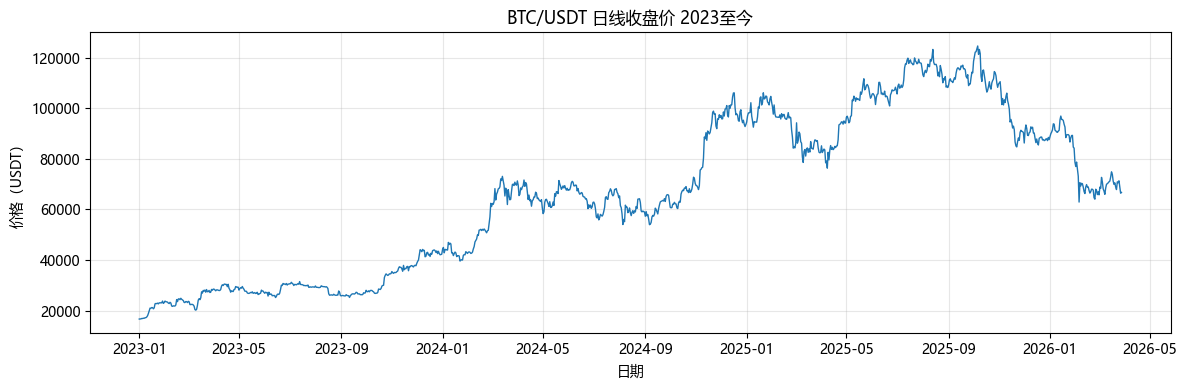

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df_btc.index, df_btc["close"], linewidth=1)
plt.title("BTC/USDT 日线收盘价 2023至今")
plt.xlabel("日期")
plt.ylabel("价格（USDT）")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
symbols = [
    "BTC/USDT", "ETH/USDT", "BNB/USDT", "SOL/USDT", "XRP/USDT",
    "DOGE/USDT", "ADA/USDT", "TRX/USDT", "HYPE/USDT", "LINK/USDT"
]

close_crypto = {}

for symbol in symbols:
    try:
        ohlcv = []
        since = exchange.parse8601("2023-01-01T00:00:00Z")
        while True:
            batch = exchange.fetch_ohlcv(symbol, timeframe="1d", since=since, limit=300)
            if len(batch) == 0:
                break
            ohlcv += batch
            since = batch[-1][0] + 86400000
            if batch[-1][0] >= exchange.milliseconds():
                break
            time.sleep(0.3)
        
        df_temp = pd.DataFrame(ohlcv, columns=["timestamp","open","high","low","close","volume"])
        df_temp["date"] = pd.to_datetime(df_temp["timestamp"], unit="ms")
        df_temp = df_temp.set_index("date")["close"]
        df_temp = df_temp[~df_temp.index.duplicated()]
        close_crypto[symbol.replace("/USDT","")] = df_temp
        print(f"完成：{symbol}")
        time.sleep(0.5)
    except Exception as e:
        print(f"失败：{symbol} {e}")

close_crypto_df = pd.DataFrame(close_crypto)
close_crypto_df.to_csv("crypto_close.csv")
print(f"\n完成，维度：{close_crypto_df.shape}")

完成：BTC/USDT
完成：ETH/USDT
完成：BNB/USDT
完成：SOL/USDT
完成：XRP/USDT
完成：DOGE/USDT
完成：ADA/USDT
完成：TRX/USDT
完成：HYPE/USDT
完成：LINK/USDT

完成，维度：(1183, 10)


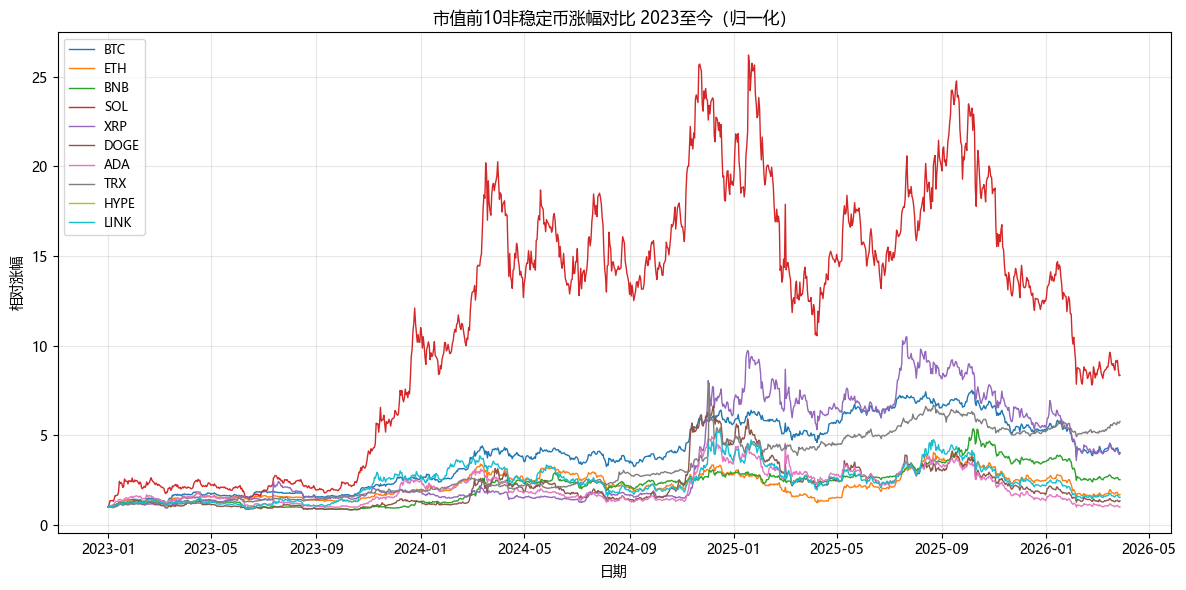

In [11]:
# 归一化到1，方便对比
close_norm = close_crypto_df / close_crypto_df.iloc[0]

plt.figure(figsize=(12, 6))
for col in close_norm.columns:
    plt.plot(close_norm.index, close_norm[col], linewidth=1, label=col)

plt.title("市值前10非稳定币涨幅对比 2023至今（归一化）")
plt.xlabel("日期")
plt.ylabel("相对涨幅")
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# 读取数据
close_crypto_df = pd.read_csv("crypto_close.csv", index_col=0, parse_dates=True)

# 计算20日动量因子
momentum = close_crypto_df / close_crypto_df.shift(20) - 1

# 未来10天涨幅（预测目标）
future_return = close_crypto_df.shift(-10) / close_crypto_df - 1

# 每天计算截面IC
ic_list = []
dates_list = []

for date in momentum.index:
    factor_row = momentum.loc[date].dropna()
    if date not in future_return.index:
        continue
    return_row = future_return.loc[date].dropna()
    common = factor_row.index.intersection(return_row.index)
    if len(common) < 5:
        continue
    ic = factor_row[common].corr(return_row[common], method="spearman")
    ic_list.append(ic)
    dates_list.append(date)

ic_momentum = pd.Series(ic_list, index=dates_list)

print(f"动量因子 IC均值：{ic_momentum.mean():.4f}")
print(f"动量因子 IC标准差：{ic_momentum.std():.4f}")
print(f"动量因子 ICIR：{ic_momentum.mean()/ic_momentum.std():.4f}")
print(f"动量因子 IC>0的比例：{(ic_momentum>0).mean():.2%}")

动量因子 IC均值：0.0270
动量因子 IC标准差：0.4183
动量因子 ICIR：0.0644
动量因子 IC>0的比例：52.21%


In [13]:
# 反转因子：过去5天跌得多的币，接下来反弹
reversal = -(close_crypto_df / close_crypto_df.shift(5) - 1)

ic_list2 = []
dates_list2 = []

for date in reversal.index:
    factor_row = reversal.loc[date].dropna()
    if date not in future_return.index:
        continue
    return_row = future_return.loc[date].dropna()
    common = factor_row.index.intersection(return_row.index)
    if len(common) < 5:
        continue
    ic = factor_row[common].corr(return_row[common], method="spearman")
    ic_list2.append(ic)
    dates_list2.append(date)

ic_reversal = pd.Series(ic_list2, index=dates_list2)

print(f"反转因子 IC均值：{ic_reversal.mean():.4f}")
print(f"反转因子 IC标准差：{ic_reversal.std():.4f}")
print(f"反转因子 ICIR：{ic_reversal.mean()/ic_reversal.std():.4f}")
print(f"反转因子 IC>0的比例：{(ic_reversal>0).mean():.2%}")

反转因子 IC均值：0.0023
反转因子 IC标准差：0.3879
反转因子 ICIR：0.0059
反转因子 IC>0的比例：49.83%


In [14]:
# 计算MACD
close = close_crypto_df["BTC"].dropna()

# EMA12 和 EMA26
ema12 = close.ewm(span=12, adjust=False).mean()
ema26 = close.ewm(span=26, adjust=False).mean()

# MACD线 和 信号线
macd = ema12 - ema26
signal = macd.ewm(span=9, adjust=False).mean()

# 金叉死叉信号
cross = pd.Series(0, index=close.index)
cross[macd > signal] = 1   # 金叉：持仓
cross[macd < signal] = 0   # 死叉：空仓

print(f"持仓天数比例：{cross.mean():.2%}")
print(cross.value_counts())

持仓天数比例：48.77%
0    606
1    577
Name: count, dtype: int64


MACD策略 累计收益：135.44%
MACD策略 年化收益：30.27%
MACD策略 最大回撤：-32.10%
MACD策略 Sharpe：0.9987
BTC买入持有 累计收益：301.92%


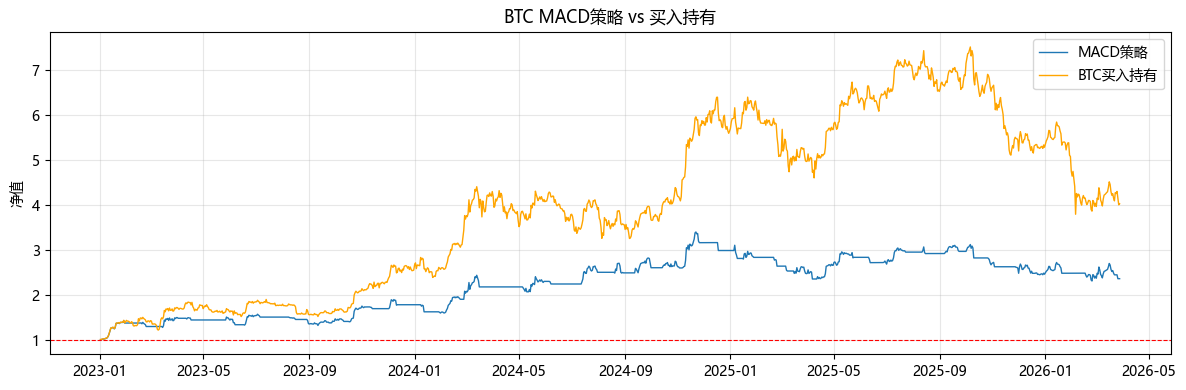

In [16]:
# MACD择时回测
returns = close.pct_change().dropna()
signal_shifted = cross.shift(1).dropna()  # 用昨天的信号决定今天是否持仓

# 对齐
common = returns.index.intersection(signal_shifted.index)
strategy_returns = returns[common] * signal_shifted[common]

# 计算净值
portfolio = (1 + strategy_returns).cumprod()
buy_hold = (1 + returns[common]).cumprod()

# 指标
total_return = portfolio.iloc[-1] - 1
annual_return = (1 + total_return) ** (365/len(portfolio)) - 1
max_drawdown = ((portfolio - portfolio.cummax()) / portfolio.cummax()).min()
sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(365)
bh_return = buy_hold.iloc[-1] - 1

print(f"MACD策略 累计收益：{total_return:.2%}")
print(f"MACD策略 年化收益：{annual_return:.2%}")
print(f"MACD策略 最大回撤：{max_drawdown:.2%}")
print(f"MACD策略 Sharpe：{sharpe:.4f}")
print(f"BTC买入持有 累计收益：{bh_return:.2%}")

# 画图
plt.figure(figsize=(12, 4))
plt.plot(portfolio.index, portfolio, linewidth=1, label="MACD策略")
plt.plot(buy_hold.index, buy_hold, linewidth=1, label="BTC买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("BTC MACD策略 vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# 测试不同参数组合
results = []

for fast in [8, 12, 16, 20]:
    for slow in [21, 26, 30, 35]:
        for signal_period in [7, 9, 12]:
            if fast >= slow:
                continue
            
            ema_fast = close.ewm(span=fast, adjust=False).mean()
            ema_slow = close.ewm(span=slow, adjust=False).mean()
            macd_line = ema_fast - ema_slow
            signal_line = macd_line.ewm(span=signal_period, adjust=False).mean()
            
            cross = pd.Series(0, index=close.index)
            cross[macd_line > signal_line] = 1
            cross[macd_line < signal_line] = 0
            
            ret = close.pct_change().dropna()
            sig = cross.shift(1).dropna()
            common = ret.index.intersection(sig.index)
            strat_ret = ret[common] * sig[common]
            
            pv = (1 + strat_ret).cumprod()
            total_ret = pv.iloc[-1] - 1
            sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
            dd = ((pv - pv.cummax()) / pv.cummax()).min()
            
            results.append({
                "fast": fast, "slow": slow, "signal": signal_period,
                "累计收益": total_ret, "Sharpe": sharpe, "最大回撤": dd
            })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("Sharpe", ascending=False)
print(df_results.head(10).to_string(index=False))

 fast  slow  signal     累计收益   Sharpe      最大回撤
   16    35       9 3.389462 1.607901 -0.216499
   20    26      12 3.205109 1.578501 -0.248990
   16    30      12 3.172889 1.573581 -0.221713
   20    30       9 3.144332 1.560335 -0.219086
   20    35       9 2.934959 1.521389 -0.235412
   20    26       9 2.936256 1.499362 -0.244605
   20    30       7 2.823132 1.472624 -0.223286
   20    35       7 2.728440 1.458487 -0.231127
   16    26      12 2.684006 1.437991 -0.244605
   20    21      12 2.644962 1.437645 -0.242010
